In [53]:
import matplotlib.pyplot as plt
import numpy as np

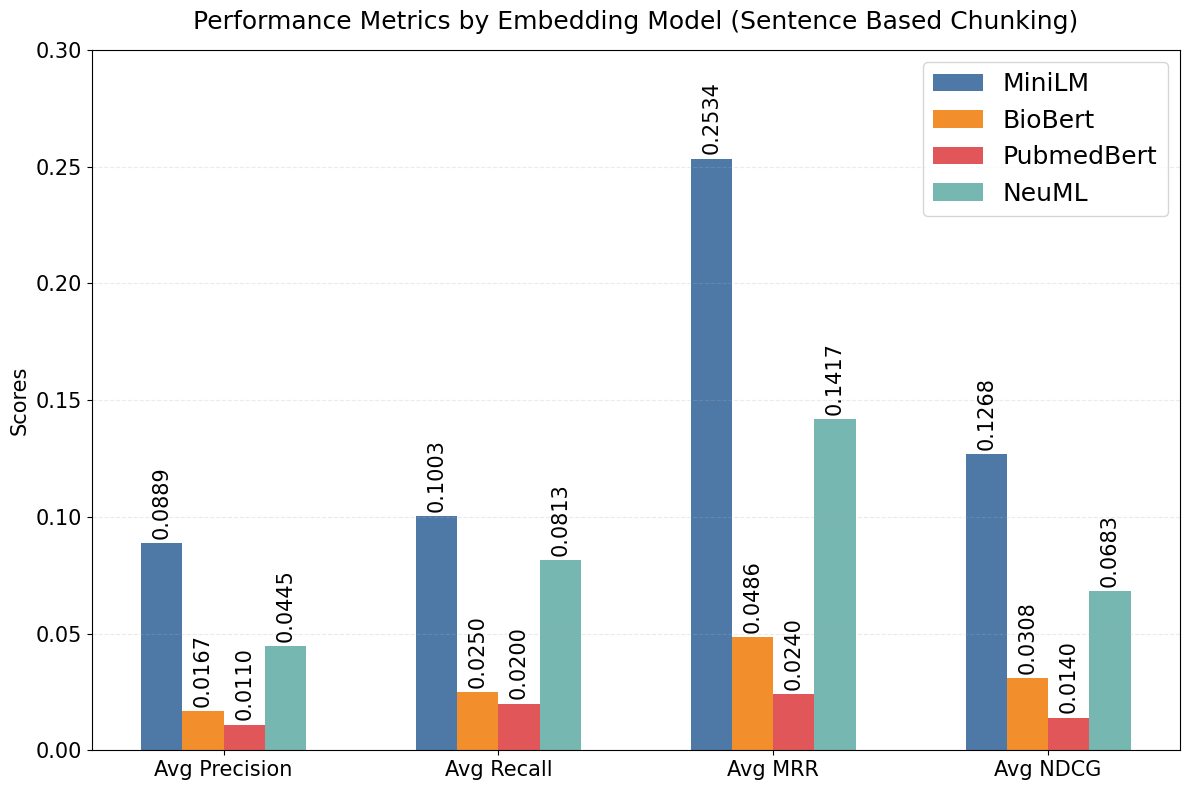

In [54]:
# Data Extraction
models = ['MiniLM', 'BioBert', 'PubmedBert', 'NeuML']
metrics = ['Avg Precision', 'Avg Recall', 'Avg MRR', 'Avg NDCG']

# Data organized by metric for plotting
# {Metric: [MiniLM, BioBert, PubmedBert, NeuML]}
data = {
    'Avg Precision': [0.0889, 0.0167, 0.0110, 0.0445],
    'Avg Recall':    [0.1003, 0.0250, 0.0200, 0.0813],
    'Avg MRR':       [0.2534, 0.0486, 0.0240, 0.1417],
    'Avg NDCG':      [0.1268, 0.0308, 0.0140, 0.0683]
}

# Setup the Figure (only one plot now)
fig, ax1 = plt.subplots(figsize=(12, 8))

# --- Plot: Grouped Bar Chart ---
x = np.arange(len(metrics))  # Label locations
width = 0.15  # Width of the bars

# Create bars with offsets
rects1 = ax1.bar(x - 1.5*width, [data[m][0] for m in metrics], width, label='MiniLM', color='#4e79a7')
rects2 = ax1.bar(x - 0.5*width, [data[m][1] for m in metrics], width, label='BioBert', color='#f28e2b')
rects3 = ax1.bar(x + 0.5*width, [data[m][2] for m in metrics], width, label='PubmedBert', color='#e15759')
rects4 = ax1.bar(x + 1.5*width, [data[m][3] for m in metrics], width, label='NeuML', color='#76b7b2')

# Styling and Labels for Bar Chart
ax1.set_ylabel('Scores', fontsize=15)
ax1.set_title('Performance Metrics by Embedding Model (Sentence Based Chunking)', fontsize=18, pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(metrics, fontsize=15)
ax1.legend(loc='upper right', fontsize=18)
ax1.grid(axis='y', linestyle='--', alpha=0.25)
ax1.set_ylim(0, 0.30)  # Adjusted for max value ~0.25
ax1.tick_params(axis='y', labelsize=15)

# Function to add labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax1.annotate(f'{height:.4f}',
                     xy=(rect.get_x() + rect.get_width() / 2, height),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=15, rotation=90)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)

# Save the plot
plt.tight_layout()
plt.savefig('embedding_model_vs_sentence_chunking_plots.png')
plt.show()

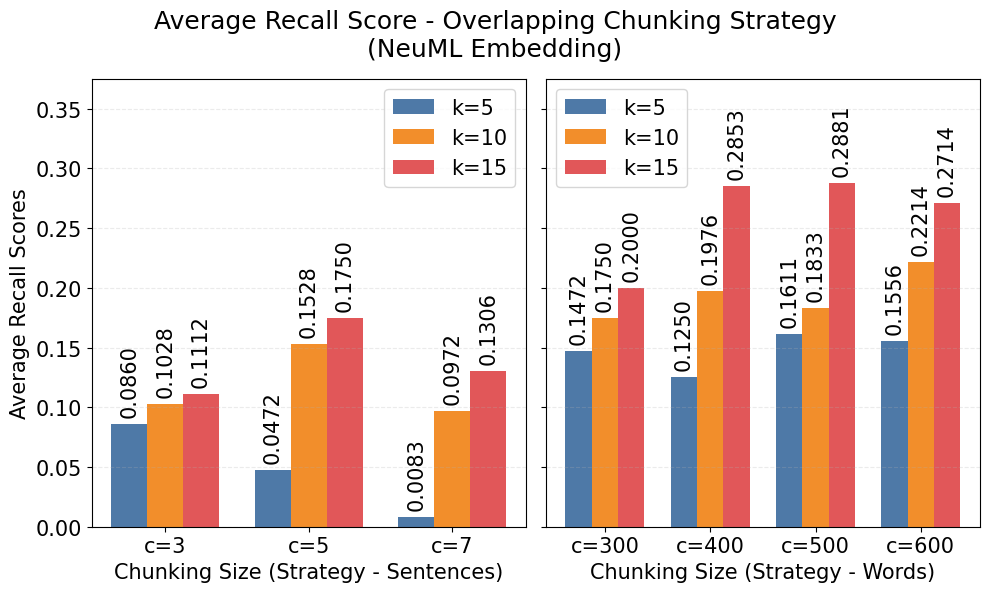

In [55]:
# ==========================================
# Data Definitions
# ==========================================

# 1. Comparison: Sentence vs Word (Recall)
sentence_chunks = ['c=3', 'c=5', 'c=7']
sentence_data = {
    'k=5':  [0.0860, 0.0472, 0.0083],
    'k=10': [0.1028, 0.1528, 0.0972],
    'k=15': [0.1112, 0.1750, 0.1306]
}
word_chunks_4 = ['c=300', 'c=400', 'c=500', 'c=600']
word_data_recall = {
    'k=5':  [0.1472, 0.1250, 0.1611, 0.1556],
    'k=10': [0.1750, 0.1976, 0.1833, 0.2214],
    'k=15': [0.2000, 0.2853, 0.2881, 0.2714]
}

# 2. Comparison: Recall vs Precision (Word Chunks)
# word_data_recall is same as above
word_data_precision = {
    'k=5':  [0.0279, 0.0167, 0.0278, 0.0334],
    'k=10': [0.0390, 0.0500, 0.0389, 0.0612],
    'k=15': [0.0556, 0.0723, 0.0667, 0.0723]
}

# 3 & 4. Comparison: No Rerank vs With Rerank (c=500)
k_labels = ['k=5', 'k=10', 'k=15']
metrics_keys = ['Avg Recall', 'Avg Precision', 'Avg MRR', 'Avg NDCG']
metrics_titles = ['Average Recall', 'Average Precision', 'Average MRR', 'Average NDCG']

data_no_rerank = {
    'Avg Recall':    [0.1611, 0.1833, 0.2881],
    'Avg Precision': [0.0278, 0.0389, 0.0667],
    'Avg MRR':       [0.1597, 0.1716, 0.1895],
    'Avg NDCG':      [0.0510, 0.0651, 0.0947]
}
data_with_rerank = {
    'Avg Recall':    [0.2714, 0.3285, 0.3285],
    'Avg Precision': [0.0534, 0.0667, 0.0667],
    'Avg MRR':       [0.6000, 0.6111, 0.6111],
    'Avg NDCG':      [0.1638, 0.1822, 0.1821]
}

# Shared Config
colors = {'k=5': '#4e79a7', 'k=10': '#f28e2b', 'k=15': '#e15759'}
bar_width = 0.25

# ==========================================
# Graph 1: Sentence vs Word Recall (Bar)
# ==========================================
def plot_graph_1():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

    def plot_bars(ax, cats, data, title, xlabel, legend_loc):
        x = np.arange(len(cats))
        rects1 = ax.bar(x - bar_width, data['k=5'], bar_width, label='k=5', color=colors['k=5'])
        rects2 = ax.bar(x, data['k=10'], bar_width, label='k=10', color=colors['k=10'])
        rects3 = ax.bar(x + bar_width, data['k=15'], bar_width, label='k=15', color=colors['k=15'])

        ax.set_xlabel(xlabel, fontsize=15)
        ax.set_xticks(x)
        ax.set_xticklabels(cats, fontsize=15)
        ax.tick_params(axis='y', labelsize=15)
        ax.grid(axis='y', linestyle='--', alpha=0.25)
        ax.legend(loc=legend_loc, fontsize=15)

        for rects in [rects1, rects2, rects3]:
            for rect in rects:
                height = rect.get_height()
                ax.annotate(f'{height:.4f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 5), textcoords="offset points",
                            ha='center', va='bottom', fontsize=15, rotation=90)

    fig.suptitle(
        'Average Recall Score - Overlapping Chunking Strategy\n(NeuML Embedding)',
        fontsize=18, x=0.5, y=0.98
    )
    plot_bars(ax1, sentence_chunks, sentence_data, "", "Chunking Size (Strategy - Sentences)", "upper right")
    ax1.set_ylabel('Average Recall Scores', fontsize=15)

    plot_bars(ax2, word_chunks_4, word_data_recall, "", "Chunking Size (Strategy - Words)", "upper left")

    plt.ylim(0, 0.375)
    plt.tight_layout()
    plt.savefig('graph1_sentence_vs_word_recall_large.png')
    # plt.close()
    plt.show()

# Run all
plot_graph_1()

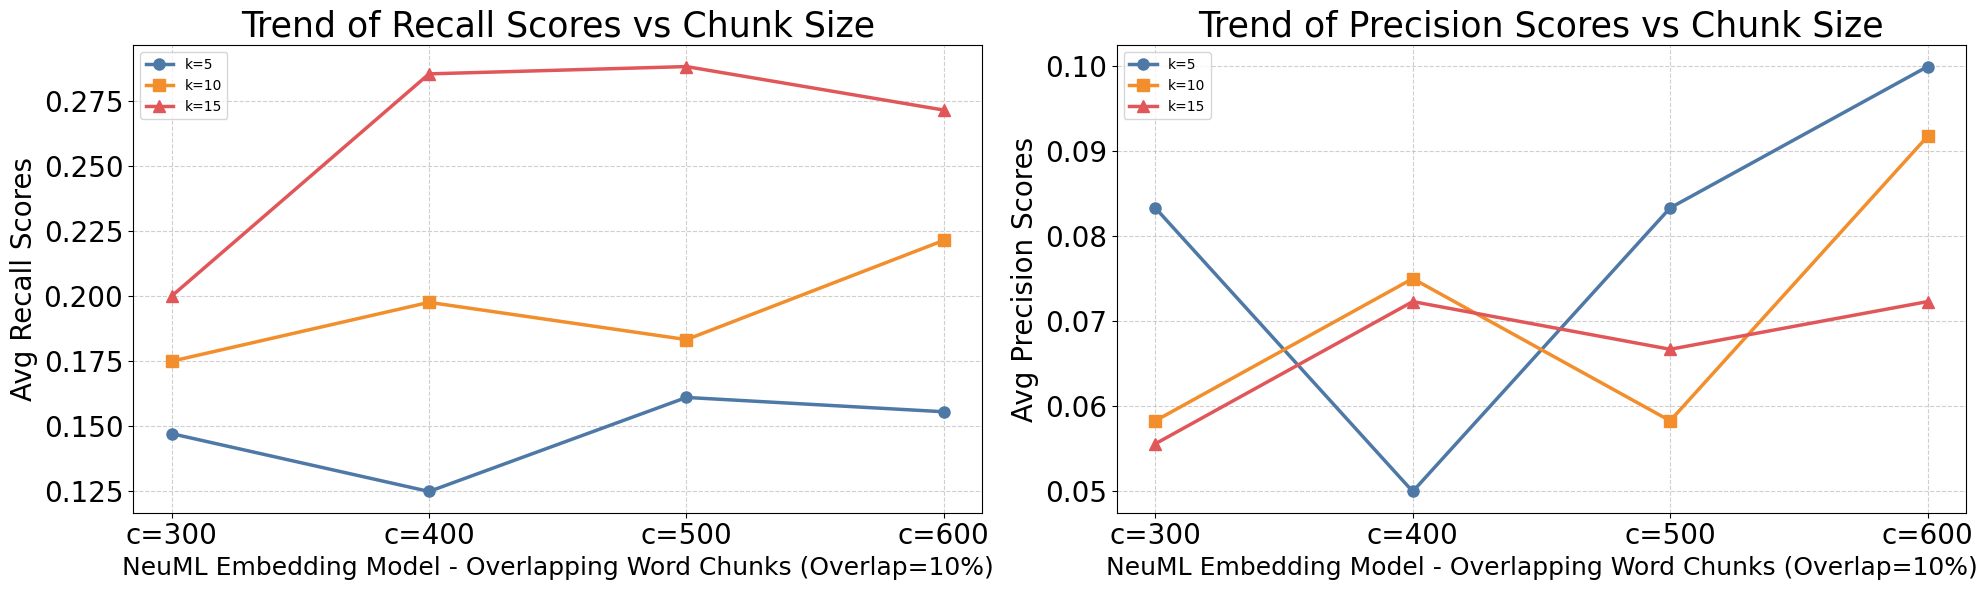

In [56]:
# Data Extraction
chunk_sizes = ['c=300', 'c=400', 'c=500', 'c=600']
x = np.arange(len(chunk_sizes))

# Recall Data
recall_k5 = [0.1472, 0.1250, 0.1611, 0.1556]
recall_k10 = [0.1750, 0.1976, 0.1833, 0.2214]
recall_k15 = [0.2000, 0.2853, 0.2881, 0.2714]

# Precision Data
precision_k5 = [0.0833, 0.0500, 0.0833, 0.0999]
precision_k10 = [0.0583, 0.0750, 0.0583, 0.0917]
precision_k15 = [0.0556, 0.0723, 0.0667, 0.0723]

# Create figure and axes
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Plot settings
colors = ['#4e79a7', '#f28e2b', '#e15759']  # Blue, Orange, Red
markers = ['o', 's', '^']                   # Circle, Square, Triangle
labels = ['k=5', 'k=10', 'k=15']

# Helper function to plot each subplot
def plot_chart(ax, data_list, title, ylabel):
    for i, data in enumerate(data_list):
        ax.plot(x, data, marker=markers[i], color=colors[i], label=labels[i], linewidth=2.5, markersize=8)

    ax.tick_params(axis='y', labelsize=20)  # Sets y-tick font size
    
    ax.set_title(title, fontsize=25)
    ax.set_ylabel(ylabel, fontsize=20)
    ax.set_xlabel('NeuML Embedding Model - Overlapping Word Chunks (Overlap=10%)', fontsize=18)
    ax.set_xticks(x)
    ax.set_xticklabels(chunk_sizes, fontsize=20)
    ax.legend(loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.6)

# Plot Left Chart (Recall)
plot_chart(axes[0], 
           [recall_k5, recall_k10, recall_k15], 
           'Trend of Recall Scores vs Chunk Size', 
           'Avg Recall Scores')

# Plot Right Chart (Precision)
plot_chart(axes[1], 
           [precision_k5, precision_k10, precision_k15], 
           'Trend of Precision Scores vs Chunk Size', 
           'Avg Precision Scores')

plt.tight_layout()
plt.savefig('recall-precision-chunk-size.png')
plt.show()

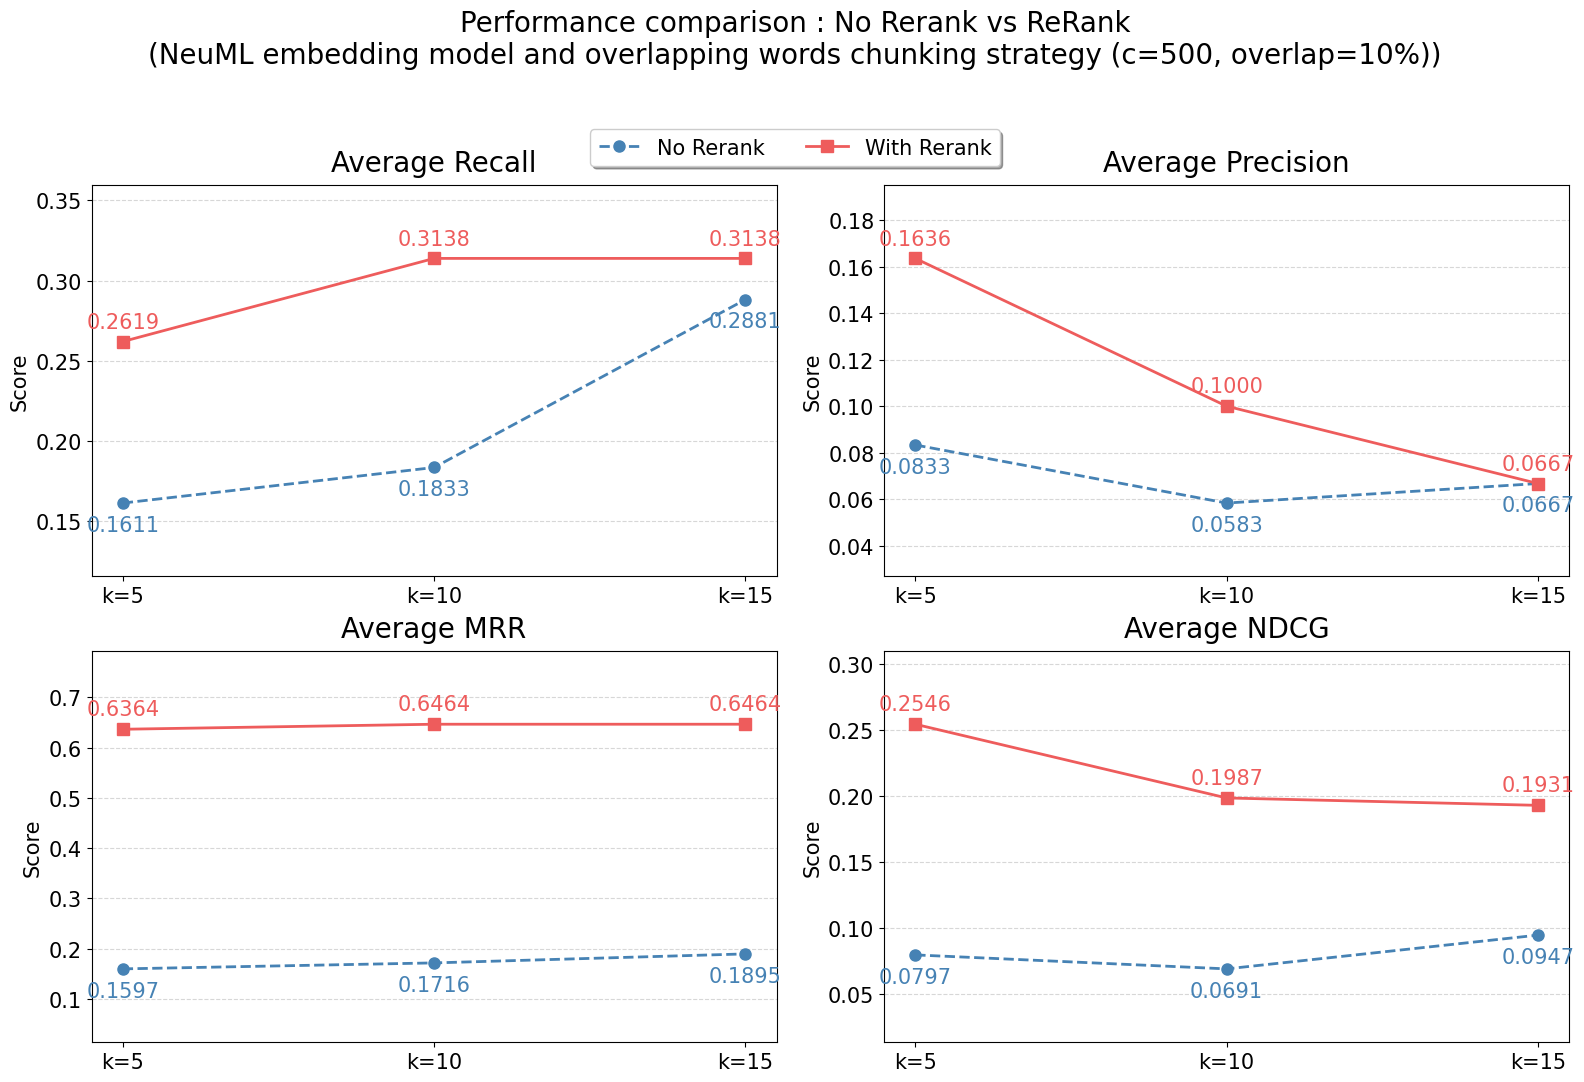

In [29]:
# --- 1. Data Setup ---
# X-axis labels
k_values = ['k=5', 'k=10', 'k=15']
x = np.arange(len(k_values))

# Data for each metric (Transcribed from the image)
data = {
    'Average Recall': {
        'No Rerank': [0.1611, 0.1833, 0.2881],
        'With Rerank': [0.2619, 0.3138, 0.3138]
    },
    'Average Precision': {
        'No Rerank': [0.0833, 0.0583, 0.0667],
        'With Rerank': [0.1636, 0.1000, 0.0667]
    },
    'Average MRR': {
        'No Rerank': [0.1597, 0.1716, 0.1895],
        'With Rerank': [0.6364, 0.6464, 0.6464]
    },
    'Average NDCG': {
        'No Rerank': [0.0797, 0.0691, 0.0947],
        'With Rerank': [0.2546, 0.1987, 0.1931]
    }
}

# --- 2. Plotting Configuration ---
# Set up the figure and a 2x2 grid of subplots
fig, axs = plt.subplots(2, 2, figsize=(16, 11))
axs = axs.flatten()

# Colors and Styles
color_no = '#4682B4'  # Steel Blue
color_yes = '#EE5C5C' # Soft Red
style_no = {'linestyle': '--', 'marker': 'o', 'linewidth': 2, 'markersize': 8}
style_yes = {'linestyle': '-', 'marker': 's', 'linewidth': 2, 'markersize': 8}

# Helper function to annotate values
def annotate_points(ax, x_vals, y_vals, color, offset_y):
    for i, val in enumerate(y_vals):
        ax.annotate(f"{val:.4f}", 
                    (x_vals[i], val), 
                    xytext=(0, offset_y), 
                    textcoords='offset points', 
                    ha='center', 
                    fontsize=15, 
                    color=color)

# --- 3. Generating the Subplots ---
metrics_list = list(data.keys())

for i, ax in enumerate(axs):
    metric = metrics_list[i]
    y_no = data[metric]['No Rerank']
    y_yes = data[metric]['With Rerank']
    
    # Plot Lines
    l1, = ax.plot(x, y_no, color=color_no, label='No Rerank', **style_no)
    l2, = ax.plot(x, y_yes, color=color_yes, label='With Rerank', **style_yes)
    
    # Annotate Values
    # Blue (No Rerank) -> Text below
    annotate_points(ax, x, y_no, color_no, -20)
    # Red (With Rerank) -> Text above
    annotate_points(ax, x, y_yes, color_yes, 10)
    
    # Formatting
    ax.set_title(metric, fontsize=20, pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(k_values)
    ax.set_ylabel("Score", fontsize=15)
    ax.tick_params(axis='x', labelsize=15)
    
    # Grid and Spines
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(True) # Keep box style
    ax.spines['right'].set_visible(True)
    
    # Adjust Y-limits to make room for annotations
    all_y = y_no + y_yes
    y_range = max(all_y) - min(all_y)
    ax.set_ylim(min(all_y) - y_range*0.3, max(all_y) + y_range*0.3)

# --- 4. Global Titles and Legend ---
# Main Title
fig.suptitle(
    "Performance comparison : No Rerank vs ReRank\n"
    "(NeuML embedding model and overlapping words chunking strategy (c=500, overlap=10%))",
    fontsize=20, y=0.98
)

# Global Legend
# We create a single legend for the whole figure
legend_lines = [
    plt.Line2D([0], [0], color=color_no, **style_no),
    plt.Line2D([0], [0], color=color_yes, **style_yes)
]
fig.legend(legend_lines, ['No Rerank', 'With Rerank'], 
           loc='upper center', bbox_to_anchor=(0.5, 0.88), 
           ncol=2, fancybox=True, shadow=True, fontsize=15)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.subplots_adjust(top=0.82) # Leave space for title and legend

# Show plot
plt.savefig('rerank.png')
plt.show()

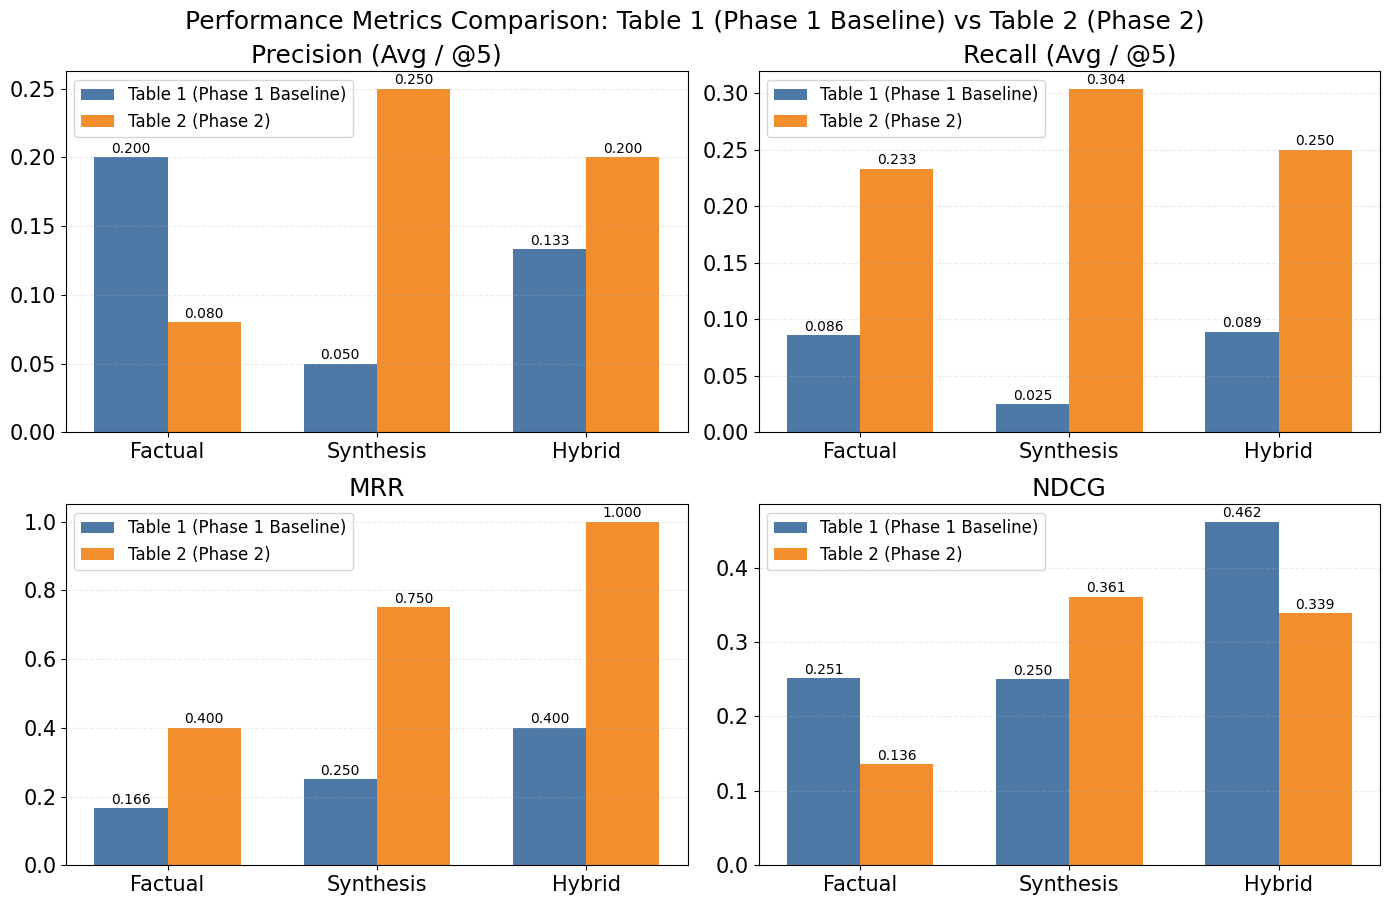

In [57]:
# Data Extraction
categories = ['Factual', 'Synthesis', 'Hybrid']

# Metrics for Table 1 (Order: Factual, Synthesis, Hybrid)
# Extracted from image_718211.png
t1_precision = [0.2, 0.05, 0.133]
t1_recall = [0.086, 0.025, 0.089]
t1_mrr = [0.166, 0.25, 0.4]
t1_ndcg = [0.2512, 0.25, 0.462]

# Metrics for Table 2 (Order: Factual, Synthesis, Hybrid)
# Extracted from image_718539.png. Note: Table 2 columns are Factual, Hybrid, Synthesis.
# I have re-ordered them here to match the list ['Factual', 'Synthesis', 'Hybrid']
t2_precision = [0.080, 0.250, 0.200]
t2_recall = [0.233, 0.304, 0.250]
t2_mrr = [0.400, 0.750, 1.000]
t2_ndcg = [0.136, 0.361, 0.339]

# Setup for plotting
x = np.arange(len(categories))  # label locations
width = 0.35  # width of the bars

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Performance Metrics Comparison: Table 1 (Phase 1 Baseline) vs Table 2 (Phase 2)', fontsize=18, y=0.93)

# Function to generate subplots
def plot_metric(ax, metric_t1, metric_t2, metric_name):
    rects1 = ax.bar(x - width/2, metric_t1, width, label='Table 1 (Phase 1 Baseline)', color='#4e79a7')
    rects2 = ax.bar(x + width/2, metric_t2, width, label='Table 2 (Phase 2)', color='#f28e2b')
    
    ax.set_title(metric_name, fontsize=18)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, fontsize=15)
    ax.legend(fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.25)

    # Add value labels
    ax.bar_label(rects1, padding=1, fmt='%.3f', fontsize=10)
    ax.bar_label(rects2, padding=1, fmt='%.3f', fontsize=10)

# Plotting each metric
plot_metric(axs[0, 0], t1_precision, t2_precision, 'Precision (Avg / @5)')
plot_metric(axs[0, 1], t1_recall, t2_recall, 'Recall (Avg / @5)')
plot_metric(axs[1, 0], t1_mrr, t2_mrr, 'MRR')
plot_metric(axs[1, 1], t1_ndcg, t2_ndcg, 'NDCG')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.savefig('Phase 2 Comparison.png')
plt.show()